In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Load dataset
df = pd.read_csv("/content/diabetes.csv")

# Display first 5 rows
print(df.head())

# Display last 5 rows
print(df.tail())

# Dataset shape
print("Shape of dataset:", df.shape)

# Dataset information
df.info()

# Statistical summary
print(df.describe())

# Check missing values
print(df.isnull().sum())

# Check duplicate records
print("Duplicate rows:", df.duplicated().sum())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766    

In [26]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [27]:
df.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


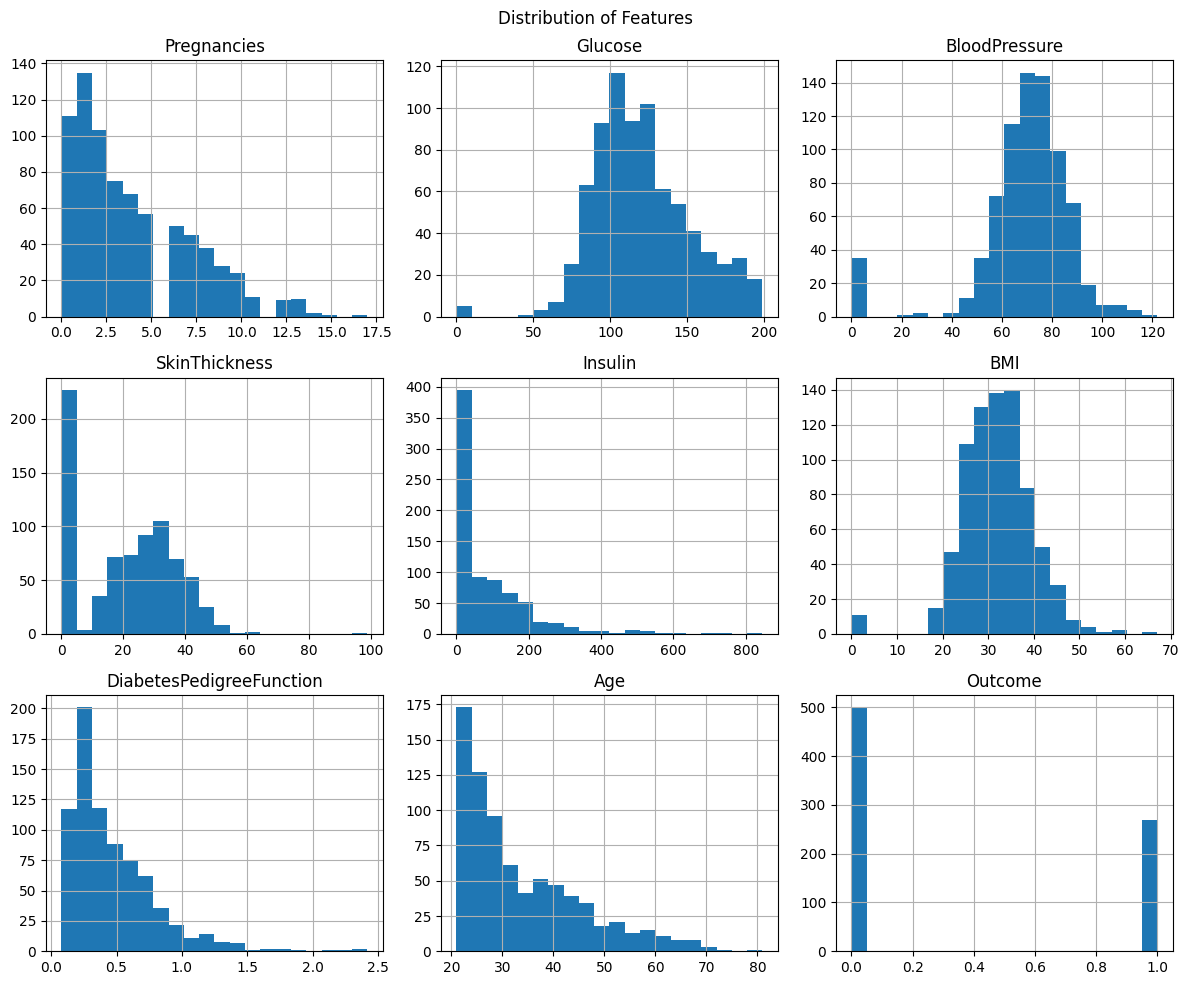

In [28]:
df.hist(figsize=(12, 10), bins=20)

plt.suptitle("Distribution of Features")
plt.tight_layout()
plt.show()

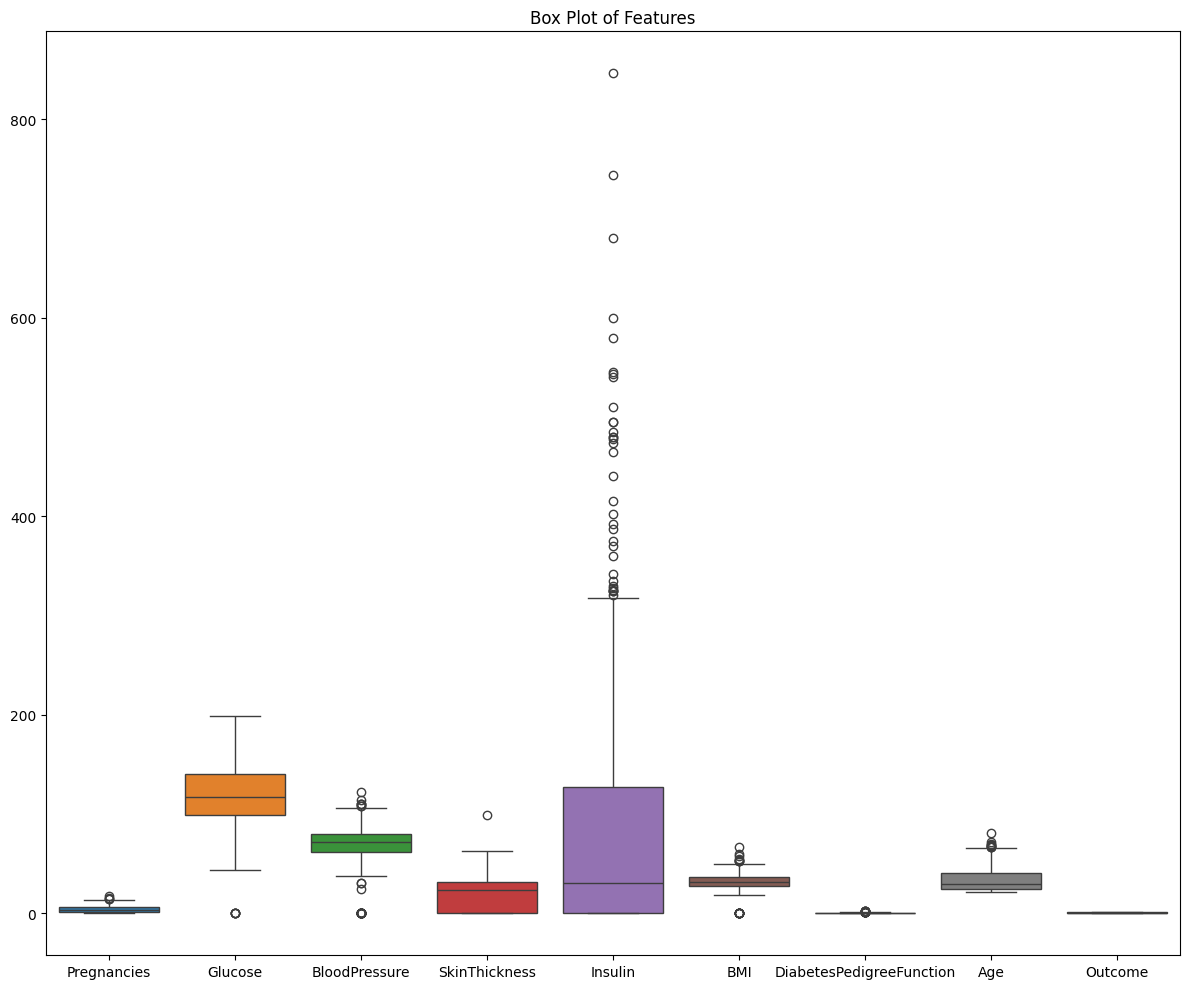

In [29]:
plt.figure(figsize=(12, 10))
sns.boxplot(data=df)
plt.title("Box Plot of Features")
plt.tight_layout()
plt.show()

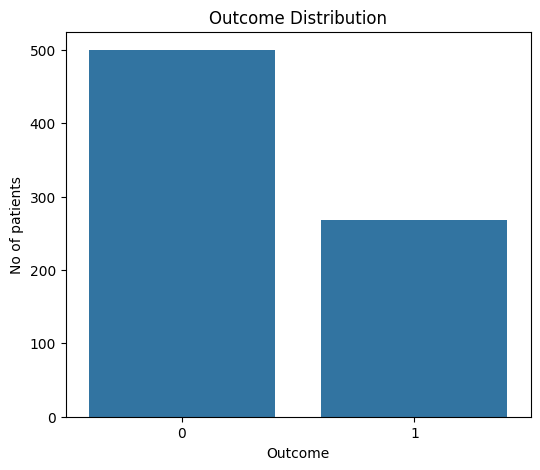

In [30]:
plt.figure(figsize=(6, 5))
sns.countplot(x="Outcome", data=df)
plt.title("Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("No of patients")
plt.show()

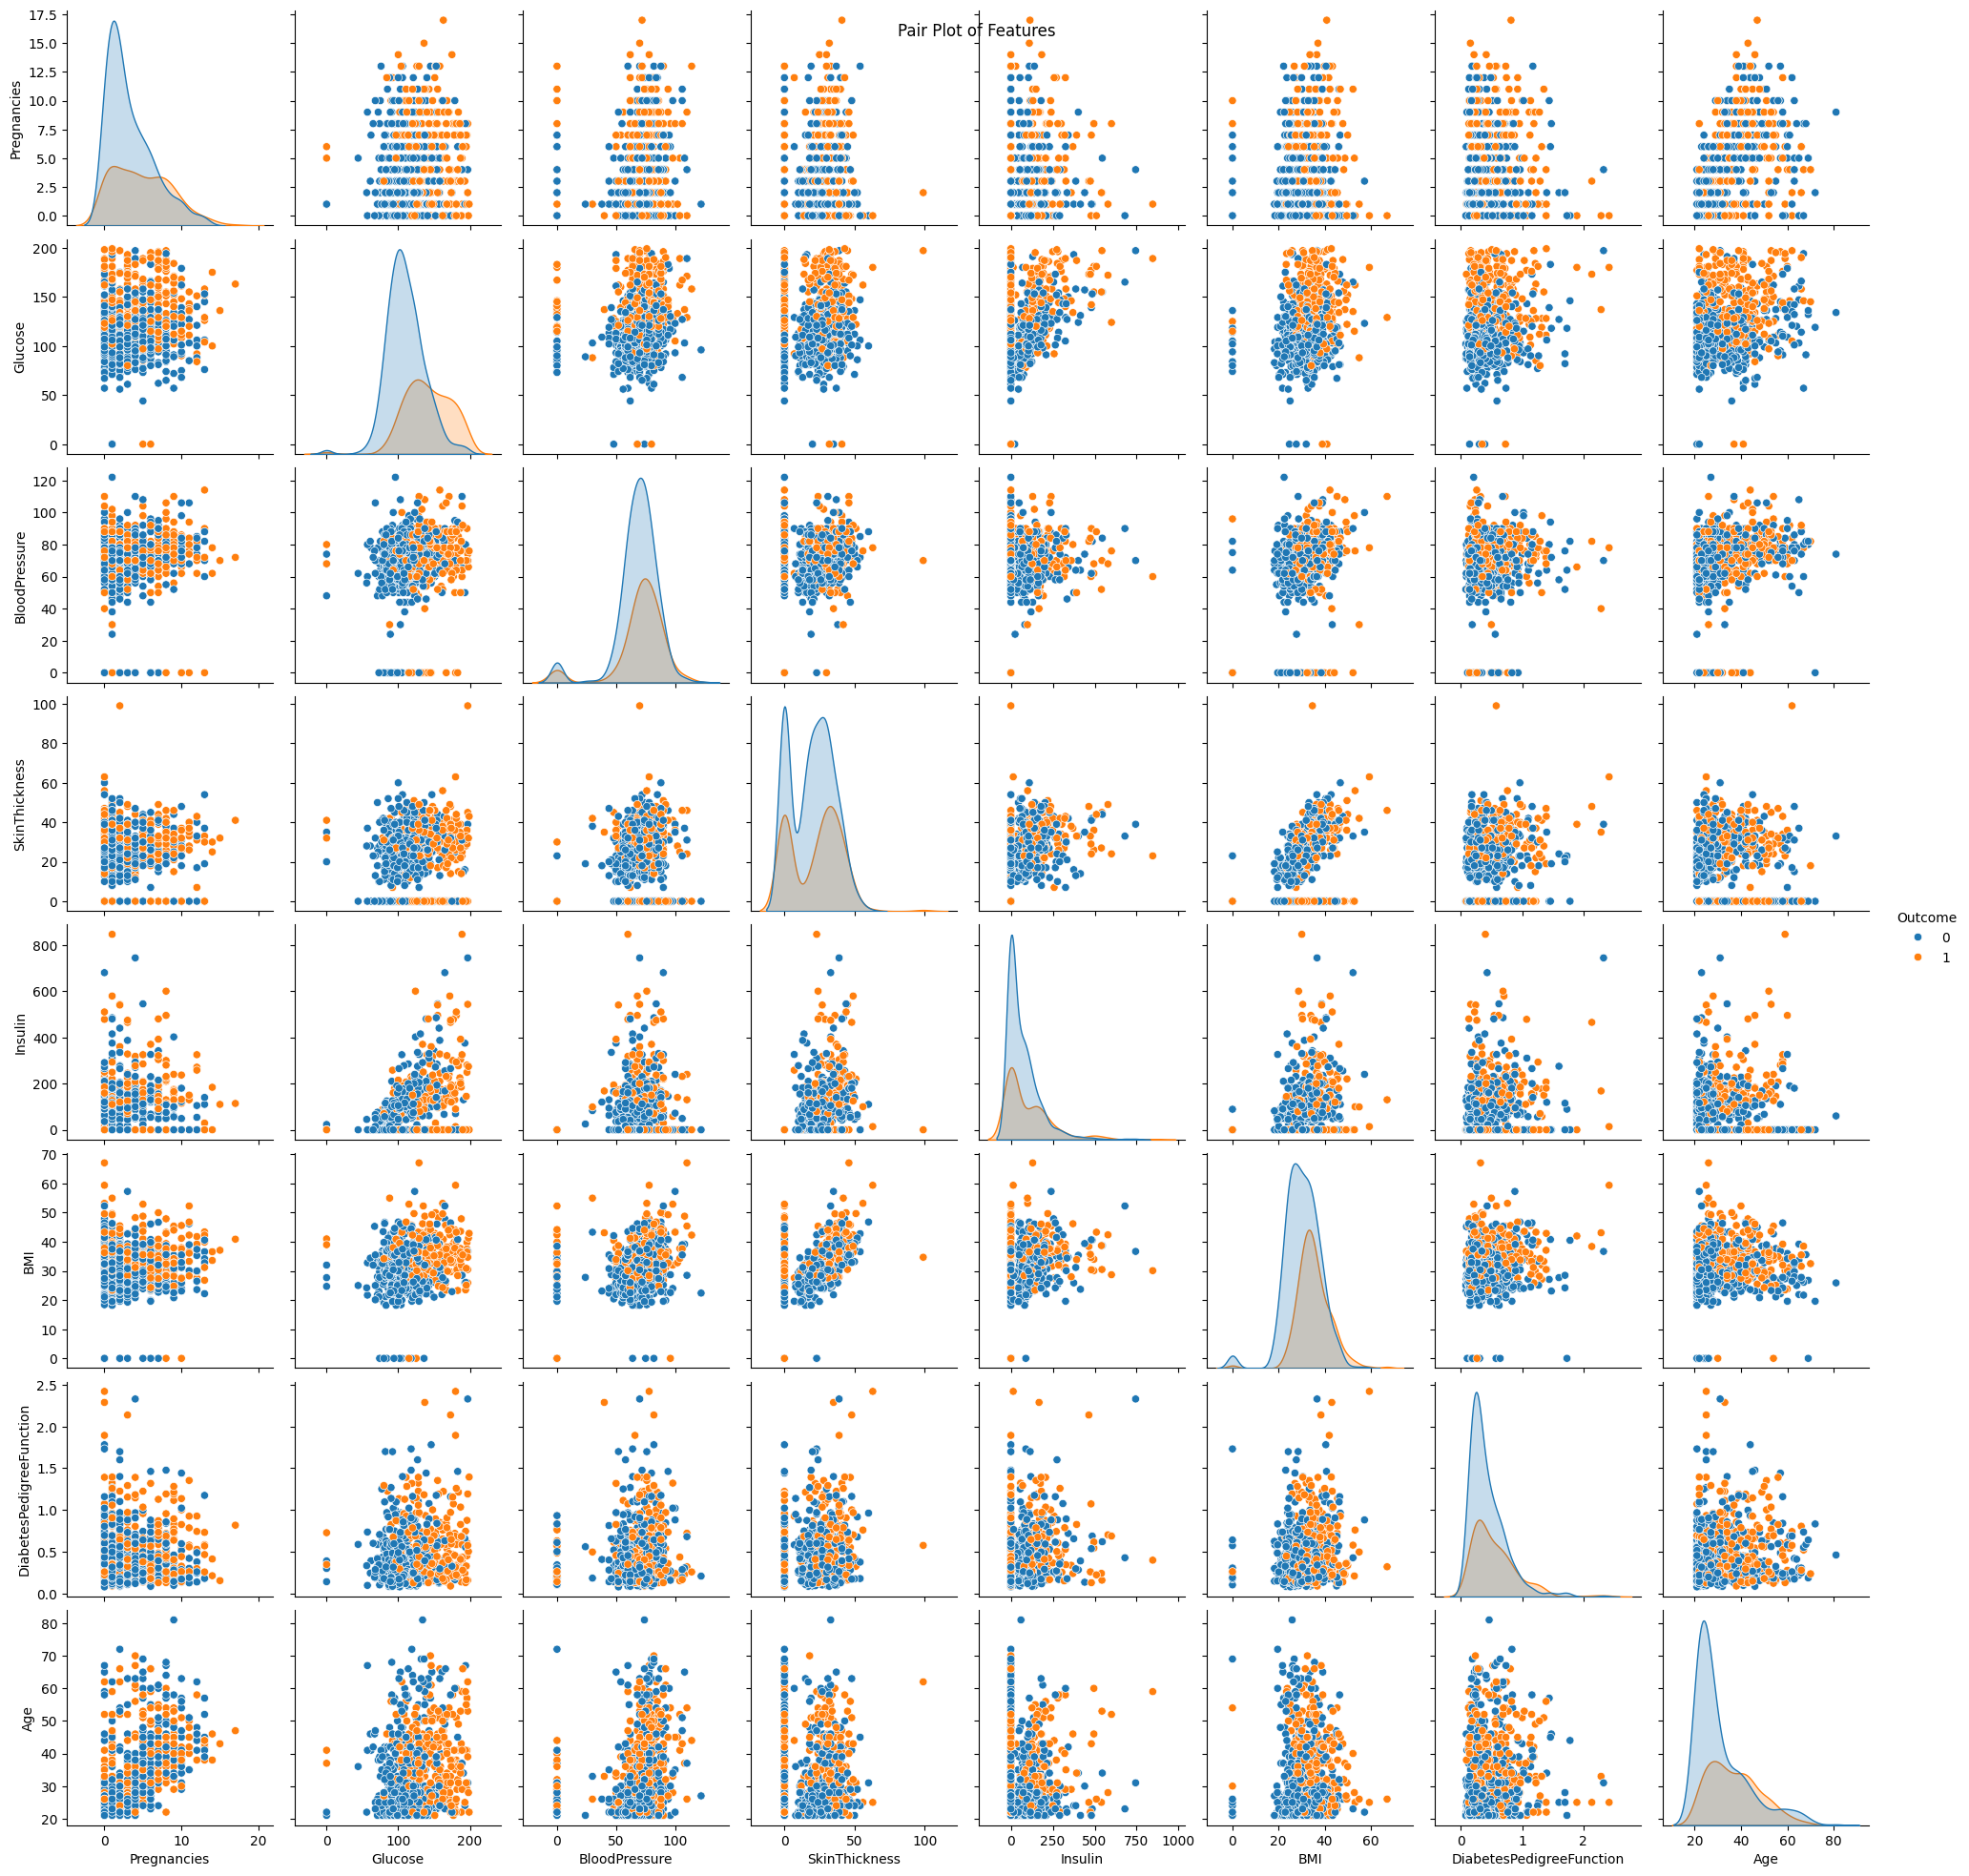

In [31]:
sns.pairplot(df, hue="Outcome")
plt.suptitle("Pair Plot of Features")
plt.show()

In [32]:
# Columns where zero values are not physiologically meaningful
columns_with_zero_as_missing = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# Replace 0 with NaN
df[columns_with_zero_as_missing] = df[
    columns_with_zero_as_missing
].replace(0, np.nan)

# Check missing values
print(df.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [33]:
columns_with_zero_as_missing = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for column in columns_with_zero_as_missing:
    df[column] = df[column].fillna(df[column].median())

print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [34]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
X_train.shape

(614, 8)

In [37]:
X_test.shape

(154, 8)

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [39]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [40]:
#predict class
y_pred = model.predict(X_test)

#predict probablity
y_pred_prob = model.predict_proba(X_test)

print("Predicted Classes:")
print(y_pred[:10])

print("\nPredicted Probabilities:")
print(y_pred_prob[:10])


Predicted Classes:
[0 0 0 0 0 0 0 0 1 1]

Predicted Probabilities:
[[0.72650648 0.27349352]
 [0.83274552 0.16725448]
 [0.89278831 0.10721169]
 [0.84589992 0.15410008]
 [0.53748186 0.46251814]
 [0.56562556 0.43437444]
 [0.98601508 0.01398492]
 [0.6160686  0.3839314 ]
 [0.4244803  0.5755197 ]
 [0.23804933 0.76195067]]


In [41]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.7532467532467533
Precision: 0.6666666666666666
Recall   : 0.6181818181818182
F1 Score : 0.6415094339622641
ROC-AUC  : 0.7232323232323232

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



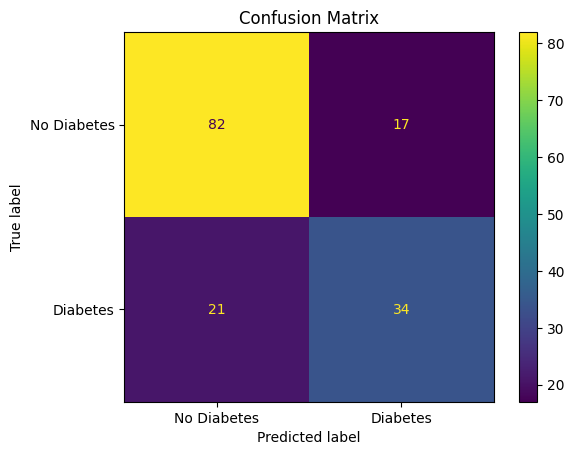

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
)

disp.plot()

plt.title("Confusion Matrix")
plt.show()

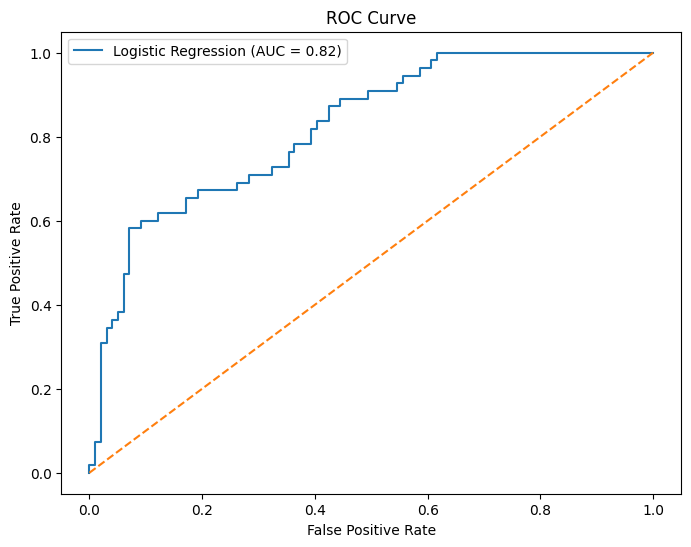

In [43]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob[:, 1])

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [44]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients["Absolute_Coefficient"] = abs(
    coefficients["Coefficient"]
)

coefficients = coefficients.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

print(coefficients)

                    Feature  Coefficient  Absolute_Coefficient
1                   Glucose     1.102682              1.102682
5                       BMI     0.688839              0.688839
7                       Age     0.392410              0.392410
0               Pregnancies     0.222978              0.222978
6  DiabetesPedigreeFunction     0.203635              0.203635
2             BloodPressure    -0.151540              0.151540
4                   Insulin    -0.138252              0.138252
3             SkinThickness     0.068836              0.068836


In [45]:
coefficients["Odds_Ratio"] = np.exp(
    coefficients["Coefficient"]
)

print(coefficients)

                    Feature  Coefficient  Absolute_Coefficient  Odds_Ratio
1                   Glucose     1.102682              1.102682    3.012233
5                       BMI     0.688839              0.688839    1.991403
7                       Age     0.392410              0.392410    1.480544
0               Pregnancies     0.222978              0.222978    1.249793
6  DiabetesPedigreeFunction     0.203635              0.203635    1.225850
2             BloodPressure    -0.151540              0.151540    0.859384
4                   Insulin    -0.138252              0.138252    0.870879
3             SkinThickness     0.068836              0.068836    1.071261


In [46]:
import joblib

joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']